# Resolución problema MMM a partir de su matriz QUBO

In [1]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import time


c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [2]:
# Obtenemos la solución clásica por fuerza bruta
def resolucion_clasica(Q_exacta, print_resultados = False):
    """
    Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).
    Parámetros
    ----------
    Q       : array-like – Matriz QUBO.
    verbose : bool       – Si True, imprime las mejores soluciones.
    Retorna
    -------
    sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
    """
    Q_exacta = np.array(Q_exacta)
#
    bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
    costs = []
    # this takes exponential time with the dimension of the QUBO
    for b in bitstrings:
        z = np.array(list(b), dtype=int)
        cost = z @ Q_exacta @ z
        costs.append(cost)
    zipped = zip(bitstrings, costs)
    sort_zipped = sorted(zipped, key=lambda x: x[1])
#
    if print_resultados:
        print(f"---Solución clásica: \n {sort_zipped[:6]} \n")
#
    return sort_zipped
# Ejecución de la función 
#sort_zipped = resolucion_clasica(Q_exacta)




# Determinamos la geometría de los átomos para Q
def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
    """
    Optimiza las coordenadas atómicas para que las interacciones Rydberg
    reproduzcan la matriz QUBO, y construye la geometría de Bloqade.
    Parámetros
    ----------
    Q       : array-like – Matriz QUBO (simétrica).
    seed    : int        – Semilla para reproducibilidad.
    tol     : float      – Tolerancia del optimizador Nelder-Mead.
    maxiter : int        – Máximo de iteraciones.
    plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.
    Retorna
    -------
    geometria : bloqade Program – Geometría lista para montar el programa.
    coords    : np.ndarray      – Coordenadas optimizadas (n×2).
    """
    Q = np.array(Q)
    device = pulser.DigitalAnalogDevice
    #
    # def evaluate_mapping(new_coords):
    #     new_coords = np.reshape(new_coords, (len(Q), 2))
    #     new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
    #     return np.linalg.norm(new_Q - Q)
    # #

    def evaluate_mapping(new_coords):
        new_coords = np.reshape(new_coords, (len(Q), 2))
        new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
        iu = np.triu_indices(len(Q), k=1)
        return np.linalg.norm(new_Q[iu] - Q[iu])


    # Por si queremos cambiar el x0:
    if x0_func is not None:
        x0 = x0_func(A, Q)
    else:
        np.random.seed(seed)
        # Escala física: distancia típica para reproducir el mayor Q_ij
        Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
        if Q_max_off > 0:
            R_typ = (device.interaction_coeff / Q_max_off) ** (1/6)
        else:
            R_typ = 5.0
        x0 = R_typ * np.random.random(len(Q) * 2)
    #
    #if random_x0 == True:
    #    np.random.seed(seed)
    #    x0 = np.random.random(len(Q) * 2)
    #elif random_x0 == False:
    #    C6 = 2 * np.pi * 862690
    #    d_init = (C6 / A) ** (1/6)
    #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init
    #
    res = minimize(
         evaluate_mapping,
         x0,
         method="Nelder-Mead",
         tol=tol,
         options={"maxiter": maxiter, "maxfev": None}
    )

    coords = np.reshape(res.x, (len(Q), 2))

    if plot:
        # Visualización Pulser
        #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
        #reg = pulser.Register(coord_dict)
        #reg.draw(
        #    blockade_radius=device.rydberg_blockade_radius(1),
        #    draw_graph=False,
        #    draw_half_radius=True,
        #)
        coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
        reg = pulser.Register(coord_dict)
        # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
        omega_max = 0.9 * np.min(-np.diag(Q))
        reg.draw(
            blockade_radius=device.rydberg_blockade_radius(omega_max),
            draw_graph=False,
            draw_half_radius=True,
        )
        print(f"Coordenadas optimizadas:\n{coords}")

    # Construcción Bloqade
    coordenadas = [tuple(pt) for pt in coords.tolist()]
    geometria = start.add_position(coordenadas)

    if plot:
        geometria.show()

    return geometria, coords
# Ejecución de la función 
#geometria, coords = construir_geometria(Q)


def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                    sweep_time=1.0, plot=False, n_shots=1000):
    """
    Ejecuta la simulación de átomos neutros para un problema QUBO dado.
    #
    Parámetros
    ----------
    Q             : array-like  – Matriz QUBO.
    geometria     : Register     – Geometría de átomos (Bloqade).
    sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
    A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
    omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    n_shots       : int          – Número de disparos de la simulación.
    sweep_time    : float        – Tiempo de evolución adiabática [µs].
    plot          : bool         – Si True, muestra el histograma.
    #
    Retorna
    -------
    prob_exito    : float        – Probabilidad de medir la solución correcta.
    counts_str    : dict         – {bitstring: conteos}.
    """
    # ── PASO 1: Detunings locales desde la diagonal de Q ──
    Q = np.array(Q)
    delta_local = -np.diag(Q)
    delta_end   = np.max(delta_local)
    escalas     = (delta_local / delta_end).tolist()
    #
    # ── PASO 2: Parámetros de pulso ──
    omega_max = 0.9 * np.min(np.abs(delta_local))
    sweep_time= sweep_time
    durations             = [0.8, sweep_time, 0.8]
    rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
    rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]
    #
    # ── PASO 3: Simulación ──
    prog = (
        geometria
        .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
        .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
    )
    emu_prog = prog.bloqade.python().run(shots=n_shots)
    report   = emu_prog.report()
    if plot:
        report.show()
    #
    #
    # ── PASO 4: Análisis ──
    counts = report.counts()[0]
    counts_str = {
        "".join(str(b) for b in estado): n
        for estado, n in counts.items()
    }
    #
    energia_minima   = sort_zipped[0][1]
    soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]
    #
    exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
    prob_exito = exitos / n_shots
    #
    # ── PASO 5: Resultados ──
    if plot:
        print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
        print(f"  Conteos solución:   {exitos} / {n_shots}")
        counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
        colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
        plt.figure(figsize=(12, 5))
        plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
        plt.xlabel("Bitstrings")
        plt.ylabel("Conteos")
        plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
        plt.xticks(rotation=90, fontsize=7)
        plt.tight_layout()
        plt.show()
    #
    return prob_exito, counts_str
# Ejecución de la función 
#prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### $P_3$

In [3]:
#Grafo P_3 (cadena de 3 nodos, 2 aristas)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P3")

Q_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_func = Q_func_P3

Q_exacta_func_P3 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B],
    [0,      -2*B+C]
])
Q_exacta_func = Q_exacta_func_P3

def x0_func_P3(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### Grafo $P_4$

In [4]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_func = Q_func_P4

Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
Q_exacta_func = Q_exacta_func_P4
# 
def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


### $P_5$

In [5]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_func = Q_func_P5

Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P5

def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### $P_5 \ modificado$ 

In [6]:
A_solucion=20
B_solucion=0.5*A_solucion
C_solucion=0.1*A_solucion

nombre_grafo = str("P5 modificado")

Q_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -4*B+C, A+2*B, 0,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  0     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_func = Q_func_P5mod


Q_exacta_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      B     ],
    [0,      -4*B+C, A+2*B, B,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  B     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P5mod


#C6 = 2 * np.pi * 862690
#d_init = (C6 / A) ** (1/6)

def x0_func_P5mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [1.5 * d, d  ],  # e4
    ]).flatten()

### $P_6$

In [7]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6")

Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P6

Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P6


# def x0_func_P6(A, Q):
#     C6 = 2 * np.pi * 862690
#     d = (C6 / A) ** (1/6)
#     return np.array([
#         [0 * d,   0.0],  # e0
#         [1 * d,   0.0],  # e1
#         [2 * d,   0.0],  # e2
#         [3 * d,   0.0],  # e3
#         [4 * d,   0.0],  # e4
#     ]).flatten()

def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    # Mayor entrada off-diagonal = A+2B (acoplamiento adyacente en L(G))
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [0*d, 0.0], [1*d, 0.0], [2*d, 0.0], [3*d, 0.0], [4*d, 0.0],
    ]).flatten()

### $P_6 \ modificado$

In [8]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6 modificado")

Q_exacta_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      B     ],
    [0,       0,    -4*B+C, A+2*B,  B,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  B     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

Q_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,  0,     0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -4*B+C, A+2*B,  0,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  0     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

def x0_func_P6mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * 2*d,    0.0],  # e0
        [1 * 2*d,    0.0],  # e1
        [2 * 2*d,    0.0],  # e2
        [3 * 2*d,    0.0],  # e3
        [4 * 2*d,    0.0],  # e4
        [2.5 * 2*d,  2*d  ],  # e5
    ]).flatten()



### Grafo Y

In [9]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=30 #0.8*A_solucion
C_solucion=10 #0.2*A_solucion

nombre_grafo = str("Y")

Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_func = Q_func_Y


Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func = Q_exacta_func_Y


def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()

### Grafo $C_4$

In [10]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4")

Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4

Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_func = Q_func_C4


def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()

### $C_4 \ modificado$ 

In [20]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4 modificado")

# C4 con un nodo extra (nodo 4) conectado al nodo 0 del ciclo
# Ciclo: 0-1-2-3-0   |   Cola: 0-4
# Grados: 0->3, 1->2, 2->2, 3->2, 4->1
#
# Aristas (variables QUBO):
#   x_0 = (0,1)
#   x_1 = (1,2)
#   x_2 = (2,3)
#   x_3 = (3,0)
#   x_4 = (0,4)  <- adyacente en L(G) tanto a x_0 como a x_3 (ambas comparten vértice 0)
#
# Diagonal: Q_ii = (1 - deg(u) - deg(v))B + C  para arista (u,v)

# Q_efectiva (truncada): solo conserva acoplamientos entre aristas adyacentes en L(G)
Q_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 0,      A+2*B, A+2*B],  # x_0=(0,1): adyacente a x_1, x_3, x_4
    [0,      -3*B+C, A+2*B, 0,     0    ],  # x_1=(1,2): adyacente a x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0    ],  # x_2=(2,3): adyacente a x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B],  # x_3=(3,0): adyacente a x_0, x_2, x_4
    [0,       0,     0,     0,    -3*B+C],  # x_4=(0,4): adyacente a x_0, x_3
])
Q_func = Q_func_C4mod


# Q_exacta: incluye los residuos cuadráticos de H_B entre pares NO adyacentes en L(G)
# Pares no adyacentes y sus coeficientes (derivados de la expansión de H_B):
#   (0,2)->2B, (1,3)->2B, (1,4)->B, (2,4)->B
Q_exacta_func_C4mod = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, 2*B,   A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B, 2*B,  B    ],
    [0,       0,    -3*B+C, A+2*B, B    ],
    [0,       0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C4mod


# def x0_func_C4mod(A, Q):
#     """
#     Geometría inicial: x_0, x_3, x_4 (las tres aristas incidentes en el vértice 0)
#     forman un triángulo equilátero de lado d. x_1, x_2 cierran el cuadrado del ciclo.
#     """
#     C6 = 2 * np.pi * 862690
#     d = (C6 / A) ** (1/6)
#     return np.array([
#         [ 0.0,             0.0   ],  # x_0 = (0,1)
#         [ d,               0.0   ],  # x_1 = (1,2)
#         [ d,               d     ],  # x_2 = (2,3)
#         [ 0.0,             d     ],  # x_3 = (3,0)
#         [-d*np.sqrt(3)/2,  d/2   ],  # x_4 = (0,4)  -> equidista de x_0 y x_3
#     ]).flatten()


def x0_func_C4mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    return np.array([
        [ 0.0,             0.0 ],
        [ d,               0.0 ],
        [ d,               d   ],
        [ 0.0,             d   ],
        [-d*np.sqrt(3)/2,  d/2 ],
    ]).flatten()

### Grafo $C_5$

In [12]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5")

Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C5

Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C5



def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_5 \ modificado$

In [22]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5 modificado")

Q_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,     A+2*B, 0    ],  # x_0=(0,1): adyac. x_1, x_4
    [0,      -3*B+C, A+2*B, 0,     0,     0    ],  # x_1=(1,2): adyac. x_0, x_2
    [0,       0,    -3*B+C, A+2*B, 0,     0    ],  # x_2=(2,3): adyac. x_1, x_3
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],  # x_3=(3,4): adyac. x_2, x_4, x_5
    [0,       0,     0,     0,    -4*B+C, A+2*B],  # x_4=(4,0): adyac. x_0, x_3, x_5
    [0,       0,     0,     0,     0,    -3*B+C],  # x_5=(4,5): adyac. x_3, x_4
])
Q_func = Q_func_C5mod

Q_exacta_func_C5mod = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,     A+2*B, B    ],
    [0,      -3*B+C, A+2*B, B,     B,     0    ],
    [0,       0,    -3*B+C, A+2*B, B,     B    ],
    [0,       0,     0,    -4*B+C, A+2*B, A+2*B],
    [0,       0,     0,     0,    -4*B+C, A+2*B],
    [0,       0,     0,     0,     0,    -3*B+C],
])
Q_exacta_func = Q_exacta_func_C5mod


# def x0_func_C5mod(A, Q):
#     """
#     Geometría inicial:
#     - Pentágono regular (x_0..x_4) de lado d, centrado en el origen.
#     - x_5 colocada de forma que x_3, x_4, x_5 formen triángulo equilátero
#       (ambas aristas incidentes al vértice 4 de G).
#     """
#     C6 = 2 * np.pi * 862690
#     d = (C6 / A) ** (1/6)
#     R = d / (2 * np.sin(np.pi / 5))
#     pent = np.array([
#         [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
#         for k in range(5)
#     ])
#     # x_5 equidistante de x_3 y x_4, a distancia d de ambas, hacia fuera del pentágono
#     p3, p4 = pent[3], pent[4]
#     mid = (p3 + p4) / 2
#     # vector perpendicular a (p4-p3), hacia fuera (lejos del centro)
#     perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
#     perp = perp / np.linalg.norm(perp)
#     if np.dot(perp, mid) < 0:
#         perp = -perp
#     p5 = mid + perp * (d * np.sqrt(3) / 2)
#     return np.vstack([pent, p5]).flatten()


def x0_func_C5mod(A, Q):
    C6 = 2 * np.pi * 862690
    Q_max_off = np.max(np.abs(Q - np.diag(np.diag(Q))))
    d = (C6 / Q_max_off) ** (1/6)
    R = d / (2 * np.sin(np.pi / 5))
    pent = np.array([
        [R*np.cos(2*np.pi*k/5 + np.pi/2), R*np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ])
    # x_5 = (4,5) en triángulo equilátero con x_3=(3,4) y x_4=(4,0)
    p3, p4 = pent[3], pent[4]
    mid = (p3 + p4) / 2
    perp = np.array([-(p4-p3)[1], (p4-p3)[0]])
    perp = perp / np.linalg.norm(perp)
    if np.dot(perp, mid) < 0:
        perp = -perp
    p5 = mid + perp * (d * np.sqrt(3) / 2)
    return np.vstack([pent, p5]).flatten()

### Grafo $K_{1'3}$

In [14]:
A = A_solucion = 45
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.3*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_K13

Q_func_K13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func = Q_func_K13


def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

# Resolución para 1 caso

---Solución clásica: 
 [('001010', np.float64(-140.0)), ('010001', np.float64(-140.0)), ('010010', np.float64(-140.0)), ('010100', np.float64(-140.0)), ('100100', np.float64(-140.0)), ('101001', np.float64(-126.0))] 



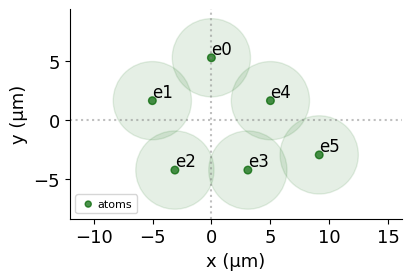

Coordenadas optimizadas:
[[ 3.31794274e-16  5.27628491e+00]
 [-5.01323407e+00  1.63342916e+00]
 [-3.09905799e+00 -4.26053763e+00]
 [ 3.09807621e+00 -4.26037059e+00]
 [ 5.01324259e+00  1.63322725e+00]
 [ 9.15634791e+00 -2.97107652e+00]]


-5013234.065717436 9156347.909267275 -4260537.631008833 5276284.905381838


A=40, B=28.0, C=14.0  →  P(éxito) = 0.00%
  Soluciones válidas: ['001010', '010001', '010010', '010100', '100100']  (E = -140.000)
  Conteos solución:   0 / 10000


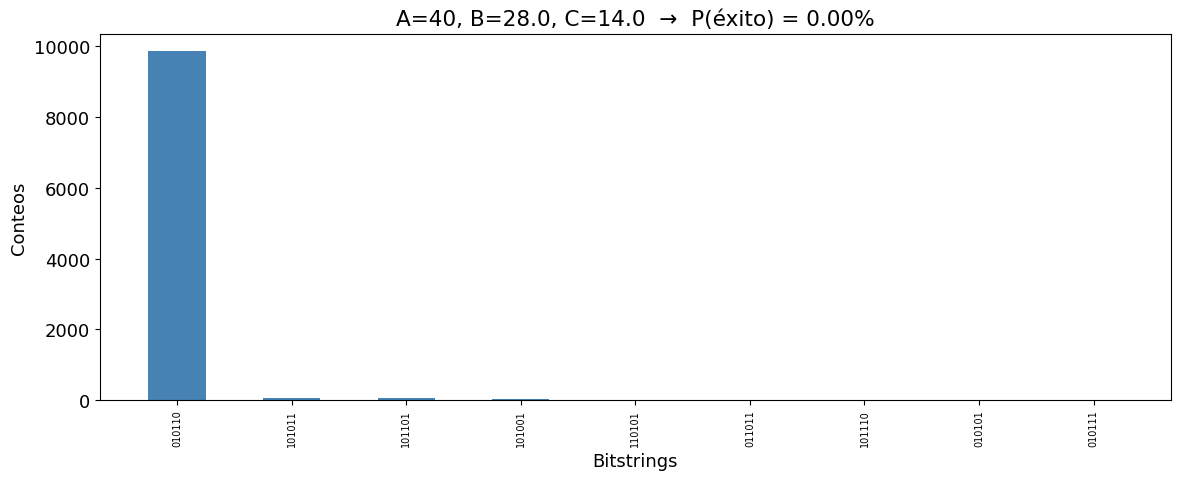

In [23]:
for k in [0.95]:
    A = A_solucion = 40#= 50 #= 10
    B = B_solucion = 0.7*A_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion = 0.35*A_solucion #= 0.2*A_solucion #= 0.2*A_solucion

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_C5mod) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=10000)

    A_values = [A]
    B_values = [B]
    C_values = [C]



# Barrido en A para varios grafos

# Heatmap variación B,C

---Solución clásica: 
 [('001010', np.float64(-140.0)), ('010001', np.float64(-140.0)), ('010010', np.float64(-140.0)), ('010100', np.float64(-140.0)), ('100100', np.float64(-140.0)), ('101001', np.float64(-126.0))] 

A=50: 0.05 s


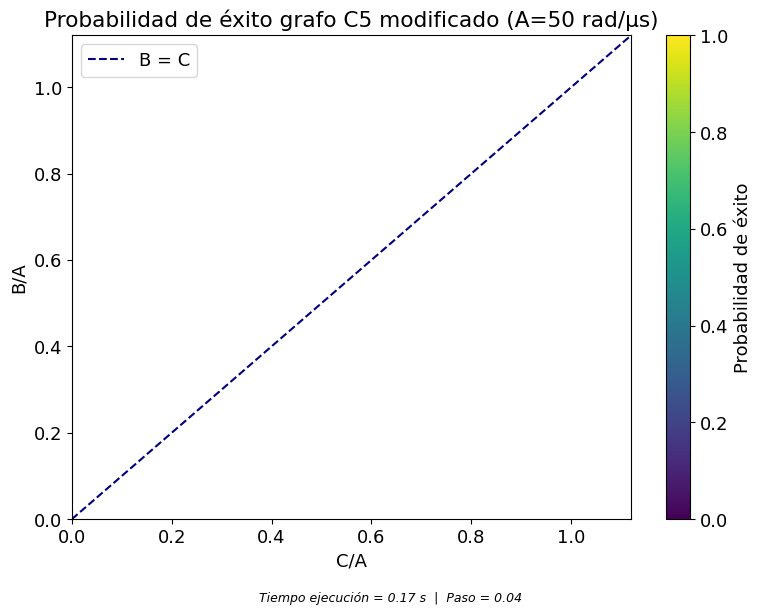

In [33]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
x0_func=x0_func_C4mod


sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [50]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.04
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casoscon detuning negativo
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue
            try:
                geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
                resultados[(A, B, C)] = prob
            except Exception:
                # Si la parametrización genera un ValidationError en Bloqade por física inválida,
                # se asigna NaN y el barrido continúa con el siguiente punto.
                resultados[(A, B, C)] = np.nan

            #geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func)
            #prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=2000)
            #resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()

# Difernecia energía $Q_{exacta}$ vs $Q_{efectiva}$

In [18]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
#    "P3":    (Q_func_P3,    Q_exacta_func_P3),
#    "P4":    (Q_func_P4,    Q_exacta_func_P4),
    "P5":    (Q_func_P5,    Q_exacta_func_P5),
    "P6":    (Q_func_P6,    Q_exacta_func_P6),
    "P7":    (Q_func_P7,    Q_exacta_func_P7),
    "P8":    (Q_func_P8,    Q_exacta_func_P8),
    "C4":    (Q_func_C4,    Q_exacta_func_C4),
    "C5":    (Q_func_C5,    Q_exacta_func_C5),
    "C6":    (Q_func_C6,    Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def min_config_simbolica(Q_func):
    """Devuelve (bitstring, E simbólica, E numérica) del mínimo de x^T Q x."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    n = Q.shape[0]
    mejor = None
    for bits in product([0, 1], repeat=n):
        x = sp.Matrix(bits)
        e = sp.expand((x.T @ Q @ x)[0, 0])
        e_num = float(e.subs(subs_num))
        if mejor is None or e_num < mejor[2]:
            mejor = (bits, e, e_num)
    return mejor[0], sp.simplify(mejor[1]), mejor[2]


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    bits_ef, E_ef, Enum_ef = min_config_simbolica(Q_func)
    bits_ex, E_ex, Enum_ex = min_config_simbolica(Q_exacta_func)
    coincide = "Sí" if bits_ef == bits_ex else "No"
    filas.append((nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide))

# ---- Impresión legible ----
header = (f"{'Grafo':<6}{'x* (ex)':<12}{'E_ex(A,B,C)':<18}{'E_ex(num)':<12}"
          f"{'x* (ef)':<12}{'E_ef(A,B,C)':<18}{'E_ef(num)':<12}{'¿Coincide?':<10}")
print(header)
print("-" * len(header))
for nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide in filas:
    print(f"{nombre:<6}{''.join(map(str,bits_ex)):<12}{str(E_ex):<18}{Enum_ex:<12.2f}"
          f"{''.join(map(str,bits_ef)):<12}{str(E_ef):<18}{Enum_ef:<12.2f}{coincide:<10}")

# ---- Tabla LaTeX ----
print(f"\n--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|c|c|}")
print(r"\hline")
print(r"Grafo & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ & $E^\text{exacta}_\text{min}$ (num) "
      r"& $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & $E^\text{efectiva}_\text{min}$ (num) "
      r"& ¿Coincide? \\")
print(r"\hline")
for nombre, bits_ex, E_ex, Enum_ex, bits_ef, E_ef, Enum_ef, coincide in filas:
    bx = ''.join(map(str, bits_ex))
    bf = ''.join(map(str, bits_ef))
    print(f"${nombre}$ & ${bx}$ & ${sp.latex(E_ex)}$ & ${Enum_ex:.2f}$ "
          f"& ${bf}$ & ${sp.latex(E_ef)}$ & ${Enum_ef:.2f}$ & {coincide} \\\\")
print(r"\hline")
print(r"\end{tabular}")

NameError: name 'Q_func_P7' is not defined

In [ ]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
#    "P3":    (Q_func_P3,    Q_exacta_func_P3),
#    "P4":    (Q_func_P4,    Q_exacta_func_P4),
#    "P5":    (Q_func_P5,    Q_exacta_func_P5),
#    "P6":    (Q_func_P6,    Q_exacta_func_P6),
    "P7":    (Q_func_P7,    Q_exacta_func_P7),
 #   "P8":    (Q_func_P8,    Q_exacta_func_P8),
 #   "C4":    (Q_func_C4,    Q_exacta_func_C4),
#    "C5":    (Q_func_C5,    Q_exacta_func_C5),
    "C6":    (Q_func_C6,    Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def dos_minimos(Q_func):
    """Devuelve los dos niveles energéticos más bajos (no degenerados entre sí)."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    n = Q.shape[0]
    todos = []
    for bits in product([0, 1], repeat=n):
        x = sp.Matrix(bits)
        e = sp.expand((x.T @ Q @ x)[0, 0])
        e_num = float(e.subs(subs_num))
        todos.append((bits, sp.simplify(e), e_num))
    todos.sort(key=lambda t: t[2])
    primero = todos[0]
    segundo = next((t for t in todos[1:] if abs(t[2] - primero[2]) > 1e-9), None)
    return primero, segundo


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    (b1_ef, E1_ef, n1_ef), (b2_ef, E2_ef, n2_ef) = dos_minimos(Q_func)
    (b1_ex, E1_ex, n1_ex), (b2_ex, E2_ex, n2_ex) = dos_minimos(Q_exacta_func)
    gap_ex = n2_ex - n1_ex
    gap_ef = n2_ef - n1_ef
    filas.append((nombre,
                  b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
                  b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef))

# ---- Impresión legible ----
print(f"Parámetros: A={A_val}, B/A={BA_val}, C/A={CA_val}  =>  B={B_val}, C={C_val}\n")
for fila in filas:
    (nombre,
     b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
     b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef) = fila
    print(f"=== {nombre} ===")
    print(f"  Q_exacta:")
    print(f"    1º: x={''.join(map(str,b1_ex))}  E={E1_ex}  (num={n1_ex:.2f})")
    print(f"    2º: x={''.join(map(str,b2_ex))}  E={E2_ex}  (num={n2_ex:.2f})")
    print(f"    gap = {gap_ex:.2f}")
    print(f"  Q_efectiva:")
    print(f"    1º: x={''.join(map(str,b1_ef))}  E={E1_ef}  (num={n1_ef:.2f})")
    print(f"    2º: x={''.join(map(str,b2_ef))}  E={E2_ef}  (num={n2_ef:.2f})")
    print(f"    gap = {gap_ef:.2f}")
    print()

# ---- Tabla LaTeX ----
print(f"--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|c|}")
print(r"\hline")
print(r"Grafo & QUBO & $\mathbf{x}^{(1)}$ & $E^{(1)}$ & $\mathbf{x}^{(2)}$ & $E^{(2)}$ & $\Delta E$ \\")
print(r"\hline")
for fila in filas:
    (nombre,
     b1_ex, E1_ex, n1_ex, b2_ex, E2_ex, n2_ex, gap_ex,
     b1_ef, E1_ef, n1_ef, b2_ef, E2_ef, n2_ef, gap_ef) = fila
    print(f"${nombre}$ & exacta & ${''.join(map(str,b1_ex))}$ & ${sp.latex(E1_ex)}$ "
          f"& ${''.join(map(str,b2_ex))}$ & ${sp.latex(E2_ex)}$ & ${gap_ex:.2f}$ \\\\")
    print(f"      & efectiva & ${''.join(map(str,b1_ef))}$ & ${sp.latex(E1_ef)}$ "
          f"& ${''.join(map(str,b2_ef))}$ & ${sp.latex(E2_ef)}$ & ${gap_ef:.2f}$ \\\\")
    print(r"\hline")
print(r"\end{tabular}")

Parámetros: A=50, B/A=0.7, C/A=0.35  =>  B=35.0, C=17.5

=== P7 ===
  Q_exacta:
    1º: x=010010  E=-6*B + 2*C  (num=-175.00)
    2º: x=010101  E=-6*B + 3*C  (num=-157.50)
    gap = 17.50
  Q_efectiva:
    1º: x=010101  E=-8*B + 3*C  (num=-227.50)
    2º: x=100101  E=-7*B + 3*C  (num=-192.50)
    gap = 35.00

=== C6 ===
  Q_exacta:
    1º: x=001001  E=-6*B + 2*C  (num=-175.00)
    2º: x=010101  E=-6*B + 3*C  (num=-157.50)
    gap = 17.50
  Q_efectiva:
    1º: x=010101  E=-9*B + 3*C  (num=-262.50)
    2º: x=000101  E=-6*B + 2*C  (num=-175.00)
    gap = 87.50

--- LaTeX (A=50, B/A=0.7, C/A=0.35) ---

\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
Grafo & QUBO & $\mathbf{x}^{(1)}$ & $E^{(1)}$ & $\mathbf{x}^{(2)}$ & $E^{(2)}$ & $\Delta E$ \\
\hline
$P7$ & exacta & $010010$ & $- 6 B + 2 C$ & $010101$ & $- 6 B + 3 C$ & $17.50$ \\
      & efectiva & $010101$ & $- 8 B + 3 C$ & $100101$ & $- 7 B + 3 C$ & $35.00$ \\
\hline
$C6$ & exacta & $001001$ & $- 6 B + 2 C$ & $010101$ & $- 6 B + 3 C$ & $17.50$ \\

In [ ]:
import sympy as sp
from itertools import product

# ---- Parámetros de referencia ----
A_val  = 50
BA_val = 0.7
CA_val = 0.35
B_val  = BA_val * A_val
C_val  = CA_val * A_val

# ---- Selección de grafos ----
grafos = {
    "P7": (Q_func_P7, Q_exacta_func_P7),
    "C6": (Q_func_C6, Q_exacta_func_C6),
}

A_sym, B_sym, C_sym = sp.symbols('A B C', positive=True, real=True)
subs_num = [(A_sym, A_val), (B_sym, B_val), (C_sym, C_val)]


def energia(Q_func, bits):
    """Energía simbólica y numérica de un bitstring."""
    Q = sp.Matrix(Q_func(A_sym, B_sym, C_sym))
    x = sp.Matrix(bits)
    e = sp.expand((x.T @ Q @ x)[0, 0])
    return sp.simplify(e), float(e.subs(subs_num))


def fundamental(Q_func, n):
    """Bitstring del estado fundamental."""
    mejor = None
    for bits in product([0, 1], repeat=n):
        E_sym, E_num = energia(Q_func, bits)
        if mejor is None or E_num < mejor[2]:
            mejor = (bits, E_sym, E_num)
    return mejor


# ---- Construcción de la tabla ----
filas = []
for nombre, (Q_func, Q_exacta_func) in grafos.items():
    Q = Q_exacta_func(A_sym, B_sym, C_sym)
    n = Q.shape[0]

    # Estados fundamentales de cada matriz
    b_ex, E_ex_sym,  E_ex_num  = fundamental(Q_exacta_func, n)
    b_ef, E_ef_sym,  E_ef_num  = fundamental(Q_func,        n)

    # Comparación 1: bitstring óptimo de Q_exacta evaluado en Q_efectiva
    E_cross_sym, E_cross_num = energia(Q_func, b_ex)
    # En Q_efectiva, el óptimo exacto queda este Delta por encima del óptimo efectivo:
    delta_ef = E_cross_num - E_ef_num

    filas.append((nombre, n,
                  b_ex, E_ex_sym, E_ex_num,
                  b_ef, E_ef_sym, E_ef_num,
                  E_cross_sym, E_cross_num, delta_ef))

# ---- Impresión legible ----
print(f"Parámetros: A={A_val}, B/A={BA_val}, C/A={CA_val}  =>  B={B_val}, C={C_val}\n")
for (nombre, n,
     b_ex, E_ex_sym, E_ex_num,
     b_ef, E_ef_sym, E_ef_num,
     E_cross_sym, E_cross_num, delta_ef) in filas:
    print(f"=== {nombre} ===")
    print(f"  x*_exacta   = {''.join(map(str,b_ex))}   E^exacta(x*_exacta)   = {E_ex_sym}  ({E_ex_num:.2f})")
    print(f"  x*_efectiva = {''.join(map(str,b_ef))}   E^efectiva(x*_efectiva)= {E_ef_sym}  ({E_ef_num:.2f})")
    print(f"  E^efectiva(x*_exacta) = {E_cross_sym}  ({E_cross_num:.2f})")
    print(f"  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = {delta_ef:.2f}")
    print()

# ---- Tabla LaTeX ----
print(f"--- LaTeX (A={A_val}, B/A={BA_val}, C/A={CA_val}) ---\n")
print(r"\begin{tabular}{|c|c|c|c|c|c|}")
print(r"\hline")
print(r"\multirow{2}{*}{Grafo} & \multicolumn{2}{c|}{$Q^\text{exacta}$} "
      r"& \multicolumn{2}{c|}{$Q^\text{efectiva}$} "
      r"& \multirow{2}{*}{$\Delta E^\text{efectiva}$} \\")
print(r"\cline{2-5}")
print(r" & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ "
      r"& $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & \\")
print(r"\hline")
for (nombre, n,
     b_ex, E_ex_sym, E_ex_num,
     b_ef, E_ef_sym, E_ef_num,
     E_cross_sym, E_cross_num, delta_ef) in filas:
    print(f"${nombre}$ & ${''.join(map(str,b_ex))}$ & ${sp.latex(E_ex_sym)}\\;({E_ex_num:.1f})$ "
          f"& ${''.join(map(str,b_ef))}$ & ${sp.latex(E_ef_sym)}\\;({E_ef_num:.1f})$ "
          f"& ${delta_ef:.1f}$ \\\\")
print(r"\hline")
print(r"\end{tabular}")

Parámetros: A=50, B/A=0.7, C/A=0.35  =>  B=35.0, C=17.5

=== P7 ===
  x*_exacta   = 010010   E^exacta(x*_exacta)   = -6*B + 2*C  (-175.00)
  x*_efectiva = 010101   E^efectiva(x*_efectiva)= -8*B + 3*C  (-227.50)
  E^efectiva(x*_exacta) = -6*B + 2*C  (-175.00)
  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = 52.50

=== C6 ===
  x*_exacta   = 001001   E^exacta(x*_exacta)   = -6*B + 2*C  (-175.00)
  x*_efectiva = 010101   E^efectiva(x*_efectiva)= -9*B + 3*C  (-262.50)
  E^efectiva(x*_exacta) = -6*B + 2*C  (-175.00)
  Delta = E^efectiva(x*_exacta) - E^efectiva(x*_efectiva) = 87.50

--- LaTeX (A=50, B/A=0.7, C/A=0.35) ---

\begin{tabular}{|c|c|c|c|c|c|}
\hline
\multirow{2}{*}{Grafo} & \multicolumn{2}{c|}{$Q^\text{exacta}$} & \multicolumn{2}{c|}{$Q^\text{efectiva}$} & \multirow{2}{*}{$\Delta E^\text{efectiva}$} \\
\cline{2-5}
 & $\mathbf{x}^*_\text{exacta}$ & $E^\text{exacta}_\text{min}$ & $\mathbf{x}^*_\text{efectiva}$ & $E^\text{efectiva}_\text{min}$ & \\
\hline
$P7$ & $010010$ &